In [1]:
# Standard libraries
import os

# Third-party libraries
import numpy as np
import pandas as pd

from astropy.table import Table

import matplotlib.pyplot as plt

# Project-specific imports
from scripts.utils.metrics import (
    calculate_flux_statistics, 
    cross_match_catalogs, 
)

from scripts.utils.evaluation_plots import (
    calculate_flux_statistics

)

### Functions

In [2]:
def compute_R_C(input_cat, output_cat, flux_col_input, flux_col_output, bins, search_radius=4.0):
    # Cross‑match catalogs
    matched_from_input = cross_match_catalogs(
        output_cat, input_cat, flux_col_output, flux_col_input, search_radius
    )
    matched_from_output = cross_match_catalogs(
        input_cat, output_cat, flux_col_input, flux_col_output, search_radius
    )

    # Prepare the table for the flux bins
    flux_bins = [(low, high) for low, high in zip(bins[:-1], bins[1:])]
    n_bins    = len(flux_bins)
    zero_list = [0] * n_bins
    nan_list  = [np.nan] * n_bins

    metrics_df = pd.DataFrame({
        'Flux bin': flux_bins,
        'TPc'     : zero_list,   # true positives for completeness
        'FNc'     : zero_list,   # false negatives for completeness
        'C'       : nan_list,    # completeness = TPc/(TPc+FNc)
        'cum_C'   : nan_list,    # cumulative completeness
        'TPr'     : zero_list,   # true positives for reliability
        'FPr'     : zero_list,   # false positives for reliability
        'R'       : nan_list,    # reliability = TPr/(TPr+FPr)
        'cum_R'   : nan_list,    # cumulative reliability
    })

    # Compute bin centers, completeness, and reliability
    for idx, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
        # --- completeness side
        in_bin     = (input_cat[flux_col_input]  >= low) & (input_cat[flux_col_input]  < high)
        n_in       = in_bin.sum()
        tp_c       = ((matched_from_input[flux_col_input] >= low) &
                      (matched_from_input[flux_col_input] < high)).sum()
        fn_c       = n_in - tp_c

        # --- reliability side
        out_bin    = (output_cat[flux_col_output] >= low) & (output_cat[flux_col_output] < high)
        n_out      = out_bin.sum()
        tp_r       = ((matched_from_output[flux_col_output] >= low) &
                      (matched_from_output[flux_col_output] < high)).sum()
        fp_r       = n_out - tp_r

        # --- completeness & reliability fractions
        comp = tp_c / n_in if n_in > 0 else np.nan
        rel  = tp_r / n_out if n_out > 0 else np.nan

        # Fill row
        metrics_df.at[idx, 'TPc'] = tp_c
        metrics_df.at[idx, 'FNc'] = fn_c
        metrics_df.at[idx,  'C']  = comp

        metrics_df.at[idx, 'TPr'] = tp_r
        metrics_df.at[idx, 'FPr'] = fp_r
        metrics_df.at[idx,  'R']  = rel

    # Compute cumulative True Positives, False Negatives etc
    metrics_df["TPr_cum"] = metrics_df["TPr"][::-1].cumsum()[::-1]
    metrics_df["FPr_cum"] = metrics_df["FPr"][::-1].cumsum()[::-1]
    metrics_df["TPc_cum"] = metrics_df["TPc"][::-1].cumsum()[::-1]
    metrics_df["FNc_cum"] = metrics_df["FNc"][::-1].cumsum()[::-1]

    # Do not compute cumulative metrics if there are no matches
    mask = (metrics_df["TPr"] + metrics_df["FPr"]) == 0
    metrics_df.loc[mask, "TPr_cum"] = np.nan
    metrics_df.loc[mask, "FPr_cum"] = np.nan

    for i in range(len(metrics_df)):
        # Compute the cumulative Completeness and Reliability
        den_C = metrics_df.loc[i, "TPc_cum"] + metrics_df.loc[i, "FNc_cum"]
        metrics_df.at[i, 'cum_C'] = metrics_df.loc[i, "TPc_cum"] / den_C if den_C > 0 else np.nan

        den_R = metrics_df.loc[i, "TPr_cum"] + metrics_df.loc[i, "FPr_cum"]
        metrics_df.at[i, 'cum_R'] = metrics_df.loc[i, "TPr_cum"] / den_R if den_R > 0 else np.nan

    # Append another column containing denominators
    metrics_df['den_C'] = metrics_df['TPc'] + metrics_df['FNc']
    metrics_df['den_R'] = metrics_df['TPr'] + metrics_df['FPr']
    metrics_df['den_C_cum'] = metrics_df['TPc_cum'] + metrics_df['FNc_cum']
    metrics_df['den_R_cum'] = metrics_df['TPr_cum'] + metrics_df['FPr_cum']

    return metrics_df

## Setup paths

In [3]:
# Paths to directories containing input and target catalogs
input_base_dir = r"/mnt/g/data/PhD Projects/SR/evaluation"
target_base_dir = r"/mnt/g/data/PhD Projects/SR/evaluation"

# Path to model results
sr_base_dir = r"/mnt/d/SPIRE-SR-AI/results/SwinUnet/{run_name}/testing/simulation_results"

# Model run names
run_names = ["deepSPIRE_default", "deepSPIRE_smoothed", "deepSPIRE_noisymips40microjy",
             "deepSPIRE_noisyspire3mjy", "deepSPIRE_noisyspire5mjy"]

# Collect path lists
input_catalog_names = ["noisy_test_input_120sqdeg_catalog.csv", "smoothed_test_input_120sqdeg_catalog.csv", "noisymips40microjy_test_input_120sqdeg_catalog.csv",
                       "noisyspire3mjy_test_input_120sqdeg_catalog.csv", "noisyspire5mjy_test_input_120sqdeg_catalog.csv"]
target_catalog_names = ["noisy_500SR_target_120sqdeg_catalog.fits", "smoothed_500SR_target_120sqdeg_catalog.fits", "noisymips40microjy_500SR_target_120sqdeg_catalog.fits",
                        "noisyspire3mjy_500SR_target_120sqdeg_catalog.fits", "noisyspire5mjy_500SR_target_120sqdeg_catalog.fits"]
sr_catalog_names = ["500SR_SR_catalog.fits", "500SR_SR_catalog.fits", "500SR_SR_catalog.fits",
                    "500SR_SR_catalog.fits", "500SR_SR_catalog.fits"]

# Labels for plotting
labels = ["Default Input", "Noise-free Input", "Noisy MIPS 40 microJy", "Noisy SPIRE 3 mJy", "Noisy SPIRE 5 mJy"]

## Compute the flux reproduction and reliability / completeness curves

In [4]:
RC_metrics = []
IQR = []

RC_flux_bins = np.logspace(np.log10(2), np.log10(80), 20, base=10) # in mJy
flux_min, flux_max = 2, 100 # in mJy

for inp_cat, target_cat, sr_cat, run_name in zip(input_catalog_names, target_catalog_names, sr_catalog_names, run_names):
    
    
    # Load catalogs
    df_input = Table.read(os.path.join(input_base_dir, inp_cat)).to_pandas()
    df_target = Table.read(os.path.join(target_base_dir, target_cat)).to_pandas()
    df_sr = Table.read(os.path.join(sr_base_dir.format(run_name=run_name), sr_cat)).to_pandas()

    df_target["source_flux_target"] *= 1000  # Convert to mJy
    df_sr["S500SR"] *= 1000                  # Convert to mJy
    df_input["SSPIRE500"] *= 1000            # Convert to mJy

    # We mask all catalogs to only include sensible fluxes for which our method is valid
    df_target = df_target[(df_target["source_flux_target"] >= flux_min) & (df_target["source_flux_target"] <= flux_max)]
    df_sr = df_sr[(df_sr["S500SR"] >= flux_min) & (df_sr["S500SR"] <= flux_max)]
    df_input = df_input[(df_input["SSPIRE500"] >= flux_min) & (df_input["SSPIRE500"] <= flux_max)]

    # Create matched catalogs
    matched_sr = cross_match_catalogs(df_sr, df_input, flux_col_source="S500SR", flux_col_target="SSPIRE500")
    matched_target = cross_match_catalogs(df_target, df_input, flux_col_source="source_flux_target", flux_col_target="SSPIRE500")

    # Calculate flux statistics
    flux_ratios = (matched_sr["S500SR"] - matched_sr["SSPIRE500"])/matched_sr["SSPIRE500"]
    flux_statistics = calculate_flux_statistics(matched_sr["SSPIRE500"], flux_ratios, num_bins=15)

    IQR.append(flux_statistics)

    # Compute completeness and reliability
    metrics_df = compute_R_C(
        df_target, df_sr,
        flux_col_input='source_flux_target',
        flux_col_output='S500SR',
        bins=RC_flux_bins,
        search_radius=4.0
    )
    RC_metrics.append(metrics_df)


## Plots

In [5]:
colors = ["#8b0023", "#0a5c36", "#fbb917", "#1f77b4", "#0eff26"]

sigma_conf = 6.8  # mJy
sigma_instr = 2 
sigma_total = np.sqrt(sigma_instr**2 + sigma_conf**2) # in mJy

### Flux reproduction

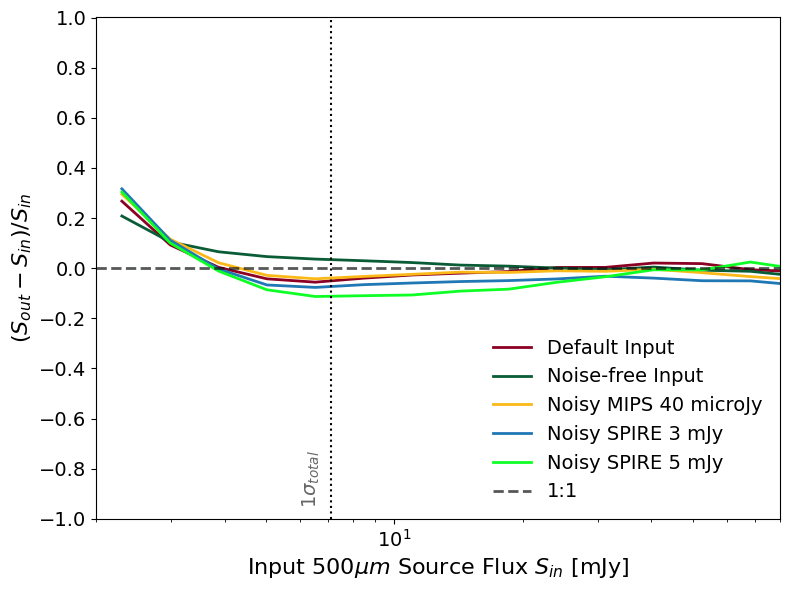

In [6]:
xlabel = r'Input 500$\mu m$ Source Flux $S_{in}$ [mJy]'
ylabel=r'$(S_{out} - S_{in})/S_{in}$'

plt.figure(figsize=(8, 6))

for i, flux_stats in enumerate(IQR):
    centers, p50, p16, p84 = flux_stats[:, 0], flux_stats[:, 1], flux_stats[:, 2], flux_stats[:, 3]

    plt.plot(
        centers, p50,
        linestyle='-', color=colors[i], label=labels[i], lw=2.0
    )

plt.axhline(0, linestyle='--', linewidth=2, color='#0e1111', alpha=0.7, label="1:1")
plt.axvline(sigma_total, color='black', linestyle=':', lw=1.5)
plt.text(sigma_total * 0.85, -0.84, r'1$\sigma_{total}$', color='black', fontsize=14, rotation=90, va='center', alpha=0.6)

# Log-scale X axis
plt.xscale('log')

# Set axis limits
plt.yticks(np.arange(-1, 1 + 0.2, 0.2))
plt.xlim([2, 80])
plt.ylim([-1, 1])

# tick labels
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=14)

# axis labels
plt.xlabel(xlabel, fontsize=16)
plt.ylabel(ylabel, fontsize=16)
plt.legend(loc='lower right', frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig('flux_recovery_comparison_retrained.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Reliability and Completeness

We do not plot the cumulative curves.

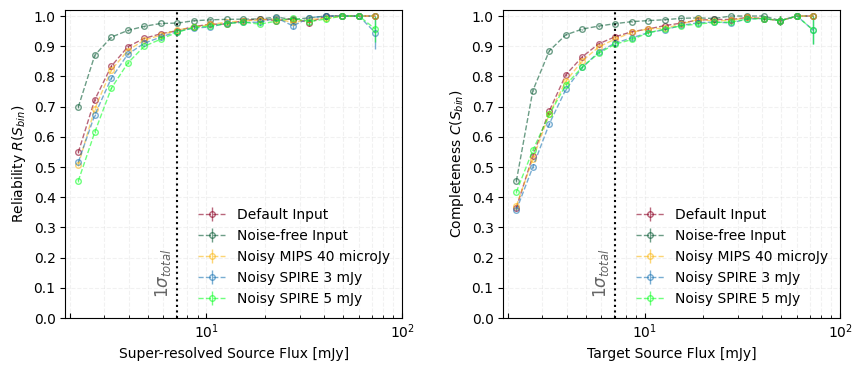

In [7]:
# Plots
threshold = 2. # mJy
flux_bins = [(low, high) for low, high in zip(RC_flux_bins[:-1], RC_flux_bins[1:])]
bin_centers = np.array([0.5 * (low + high) for low, high in flux_bins])
fig, axs = plt.subplots(nrows=1, ncols=2, sharex='col', sharey='row', figsize=(10, 4))

for i, metrics_df in enumerate(RC_metrics):

    axs[0].errorbar(bin_centers, metrics_df['R'], yerr=np.sqrt(metrics_df['R'] * (1 - metrics_df['R'])/metrics_df['den_R']), marker='o', markersize=4,
                capsize=0, capthick=0, elinewidth=1, linewidth=1, fillstyle='none', linestyle='dashed', alpha=0.6, label=labels[i], color=colors[i])

    axs[1].errorbar(bin_centers, metrics_df['C'], yerr=np.sqrt(metrics_df['C'] * (1 - metrics_df['C'])/metrics_df['den_C']), marker='o', markersize=4,
                    capsize=0, capthick=0, elinewidth=1, linewidth=1, fillstyle='none', linestyle='dashed', alpha=0.6, label=labels[i], color=colors[i])

for ax in np.ravel(axs):
    ax.axvline(sigma_total, color='black', linestyle=':', lw=1.5)
    ax.text(sigma_total * 0.75, 0.15, r'1$\sigma_{total}$', color='black', fontsize=12, rotation=90, va='center', alpha=0.6)

# Set the x-axis to log scale and add a minor grid
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].xaxis.set_tick_params(labelbottom=True)
axs[0].yaxis.set_tick_params(labelleft=True)
axs[0].grid(which='both', alpha=0.3, color='lightgrey', linestyle='--')
axs[1].xaxis.set_tick_params(labelbottom=True)
axs[1].yaxis.set_tick_params(labelleft=True)
axs[1].grid(which='both', alpha=0.3, color='lightgrey', linestyle='--')

# Set the axis labels and title for the main plot
axs[0].set_xlabel('Super-resolved Source Flux [mJy]', fontsize=10)
axs[1].set_xlabel('Target Source Flux [mJy]', fontsize=10)

axs[0].set_ylabel(r'Reliability $R(S_{bin})$', fontsize=10)
axs[1].set_ylabel(r'Completeness $C(S_{bin})$', fontsize=10)

axs[0].set_yticks(np.arange(0, 1.1, 0.1))
axs[1].set_yticks(np.arange(0, 1.1, 0.1))
axs[0].tick_params(direction='in', axis='x', which='both', labelsize=10)
axs[1].tick_params(direction='in', axis='x', which='both', labelsize=10)
axs[0].tick_params(axis='y', which='both', labelsize=10)
axs[1].tick_params(axis='y', which='both', labelsize=10)

axs[0].set_ylim([0., 1.02])
axs[1].set_ylim([0., 1.02])
axs[0].set_xlim([np.min(threshold)-0.1, np.max(bin_centers)+0.05])
axs[1].set_xlim([np.min(threshold)-0.1, np.max(bin_centers)+0.05])
axs[0].set_xticks(np.array([threshold, 10, 100]))
axs[1].set_xticks(np.array([threshold, 10, 100]))

axs[0].legend(loc='lower right', frameon=False)
axs[1].legend(loc='lower right', frameon=False)

# Adjust the spacing between the subplots
fig.subplots_adjust(hspace=0.3, wspace=0.3)

plt.savefig('R_C_comparison_retrained.pdf', dpi=300, bbox_inches='tight')
plt.show()